# Project 01 (basic) — reference solution: SQL — fetching data where they live

**Goal:** practise the basic SQL building blocks (SELECT, WHERE, GROUP BY, JOIN,
HAVING) on a real database — and see how SQL and pandas work together.

The database `datasets/shop.db` comes from `generate_db.py` (fixed seed 7):
**60 customers, 25 products, 800 orders** in three linked tables.

**This is the fully worked solution.** All cells have been executed.

**Reference to the script:** section 2.4 (SQL).

## 1. Opening a connection

SQLite is built into Python; `pd.read_sql` runs a query and delivers the result
directly as a DataFrame. The helper function `q(...)` saves typing.

In [1]:
import os
import sqlite3
import pandas as pd

PATH = "datasets/shop.db" if os.path.exists("datasets/shop.db") else "../datasets/shop.db"
con = sqlite3.connect(PATH)

def q(sql):
    """Runs an SQL query and returns a DataFrame."""
    return pd.read_sql(sql, con)

q("SELECT name FROM sqlite_master WHERE type = 'table'")

,name
0,customers
1,products
2,orders


## 2. SELECT, WHERE, ORDER BY, LIMIT

The first pattern: select rows, filter, sort, limit.

```sql
SELECT col1, col2 FROM table WHERE condition ORDER BY col DESC LIMIT 5
```

**Tasks:**
1. All products of the category 'Books' — name and price, by price descending.
2. How many products cost more than 50 EUR? (`COUNT(*)`)
3. The 5 most recent orders (by `ordered_on`).

In [2]:
# Task 1:
q("SELECT name, price FROM products WHERE category = 'Books' ORDER BY price DESC")

,name,price
0,Data Science in Practice,44.95
1,Python Handbook,39.95
2,Statistics Primer,29.95
3,SQL for Beginners,24.95
4,AI Overview,19.95
5,Bestselling Novel,12.95


In [3]:
# Tasks 2 and 3:
expensive = q("SELECT COUNT(*) AS n FROM products WHERE price > 50")
newest = q("SELECT * FROM orders ORDER BY ordered_on DESC LIMIT 5")
print(newest)

# Mini check:
print(int(expensive["n"][0]) == 6)

   order_id  customer_id  product_id  quantity  ordered_on
0       114           26          21         1  2024-12-28
1       557           26          15         2  2024-12-28
2       634           40           7         1  2024-12-28
3       699           48           5         3  2024-12-28
4        50            9          13         4  2024-12-27
True


## 3. GROUP BY — aggregating like groupby

**Tasks:**
1. How many products are there per category? (`COUNT(*)`, `GROUP BY`)
2. Average price per category, sorted descending (`AVG`, `ROUND(x, 2)`).
3. Orders per month: `strftime('%m', ordered_on)` extracts the month —
   is there a December peak?

      category  n
0        Books  6
1  Electronics  8
2    Household  6
3       Sports  5
      category  mean_price
0  Electronics       71.74
1    Household       49.99
2        Books       28.78
3       Sports       22.99


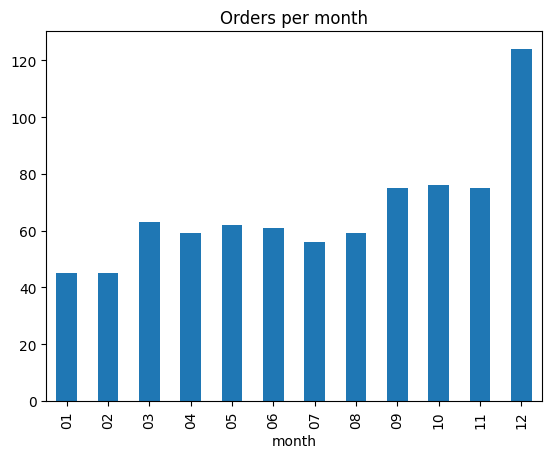

In [4]:
print(q("SELECT category, COUNT(*) AS n FROM products GROUP BY category"))
print(q("""SELECT category, ROUND(AVG(price), 2) AS mean_price
           FROM products GROUP BY category ORDER BY mean_price DESC"""))
months = q("""SELECT strftime('%m', ordered_on) AS month, COUNT(*) AS n
              FROM orders GROUP BY month ORDER BY month""")
months.plot.bar(x="month", y="n", legend=False, title="Orders per month");

## 4. JOIN — linking tables

The very reason the data sit in three tables. The pattern:

```sql
SELECT ... FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
JOIN products  p ON p.product_id  = o.product_id
```

**Tasks:**
1. Number of orders per **city** (needs: orders joined with customers).
2. **Revenue** (= `p.price * o.quantity`) per **category**, descending.
3. The **top 3 customers** by revenue (name + revenue; needs all three tables!).

In [5]:
print(q("""SELECT c.city, COUNT(*) AS n
           FROM orders o JOIN customers c ON c.customer_id = o.customer_id
           GROUP BY c.city ORDER BY n DESC"""))
revenue_by_category = q("""SELECT p.category, ROUND(SUM(p.price * o.quantity), 2) AS revenue
                           FROM orders o JOIN products p ON p.product_id = o.product_id
                           GROUP BY p.category ORDER BY revenue DESC""")
print(revenue_by_category)
top3 = q("""SELECT c.name, ROUND(SUM(p.price * o.quantity), 2) AS revenue
            FROM orders o
            JOIN products  p ON p.product_id  = o.product_id
            JOIN customers c ON c.customer_id = o.customer_id
            GROUP BY c.customer_id ORDER BY revenue DESC LIMIT 3""")
print(top3)

# Mini checks:
print(revenue_by_category["category"][0] == "Electronics")   # category with the highest revenue
print(top3["name"][0] == "Emma Schulz")                      # top customer

      city    n
0  Leipzig  176
1   Berlin  172
2  Hamburg  157
3  Cologne  150
4   Munich  145
      category   revenue
0  Electronics  28851.83
1    Household  13572.22
2        Books   8356.90
3       Sports   5587.54
            name  revenue
0    Emma Schulz  2645.26
1  Samuel Becker  1810.35
2  Tilda Mueller  1763.58
True
True


## 5. LEFT JOIN — who is missing?

A (INNER) `JOIN` shows only customers who have also ordered. But marketing asks:
**"which customers have NEVER ordered?"** For that: `LEFT JOIN` (keep all customers,
the order columns are then `NULL`) plus `WHERE o.order_id IS NULL`.

**Task:** find these customers (name, city). There should be **5** of them.

In [6]:
dormant_customers = q("""SELECT c.name, c.city
                         FROM customers c
                         LEFT JOIN orders o ON o.customer_id = c.customer_id
                         WHERE o.order_id IS NULL""")
print(dormant_customers)
print(len(dormant_customers) == 5)

             name     city
0     Tilda Meyer   Munich
1    Leon Schmidt  Hamburg
2    Paul Fischer  Cologne
3  Tilda Hoffmann   Munich
4   Clara Schmidt  Hamburg
True


## 6. WHERE vs. HAVING

`WHERE` filters rows **before** the grouping, `HAVING` filters groups **afterwards** —
only there may `COUNT(*)` and friends appear (script 2.4, self-test question 7!).

**Task:** which cities have 150 or more orders? (Expected: 4 cities.)
First deliberately try `WHERE COUNT(*) >= 150` — read the error message.

In [7]:
cities = q("""SELECT c.city, COUNT(*) AS n
              FROM orders o JOIN customers c ON c.customer_id = o.customer_id
              GROUP BY c.city
              HAVING COUNT(*) >= 150
              ORDER BY n DESC""")
print(cities)
print(len(cities) == 4)

      city    n
0  Leipzig  176
1   Berlin  172
2  Hamburg  157
3  Cologne  150
True


## 7. Division of labour: SQL + pandas

The rule of thumb from the script: **filter/join in SQL, analyse/plot in pandas.**
This is what the typical workflow looks like — SQL delivers the compact analysis
table, pandas does the rest (given as is):

category   Books  Electronics  Household  Sports
city                                            
Berlin    2011.0       4873.0     2574.0  1424.0
Cologne   1186.0       5389.0     2919.0   570.0
Hamburg   2117.0       5300.0     2634.0  1320.0
Leipzig   1577.0       8640.0     2654.0  1514.0
Munich    1465.0       4649.0     2789.0   760.0


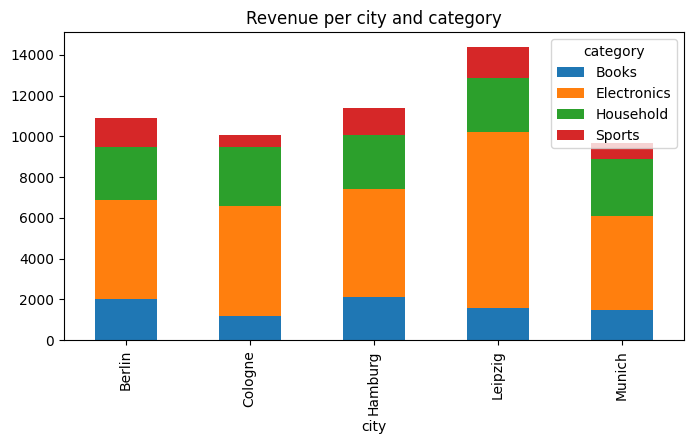

In [8]:
analysis = q("""SELECT o.ordered_on, c.city, p.category,
                       p.price * o.quantity AS revenue
                FROM orders o
                JOIN customers c ON c.customer_id = o.customer_id
                JOIN products  p ON p.product_id  = o.product_id""")
analysis["ordered_on"] = pd.to_datetime(analysis["ordered_on"])

pivot = analysis.pivot_table(index="city", columns="category",
                             values="revenue", aggfunc="sum").round(0)
print(pivot)
pivot.plot.bar(stacked=True, figsize=(8, 4), title="Revenue per city and category");

In [9]:
con.close()   # always close the connection at the end

## Done — what you can do now

- SELECT / WHERE / ORDER BY / LIMIT, aggregation with GROUP BY
- join tables via foreign keys (INNER and LEFT) — and know when to use which
- tell WHERE and HAVING apart confidently
- carry SQL results seamlessly on into pandas

**Bonus tasks** (optional):
1. Revenue per month as an SQL query (strftime + JOIN + SUM) — and as a line plot.
2. Which customer bought the most *different* products? (`COUNT(DISTINCT ...)`)
3. Rewrite the city/orders query from section 4 entirely in pandas (merge + groupby)
   and compare the results.